## Objetivo
En este laboratorio, analizarás un conjunto de datos de clientes para identificar los factores clave que influyen en la pérdida de clientes, crearás visualizaciones para explorar los datos y construirás un modelo predictivo usando aprendizaje automático. El objetivo es extraer conocimientos accionables y presentar tus hallazgos en un informe completo.
## Escenario
Eres un analista de datos en una empresa de servicios por suscripción en rápido crecimiento. La empresa está preocupada por la pérdida de clientes—clientes que cancelan sus suscripciones—y te ha encomendado analizar los datos de los clientes. Tus objetivos son identificar los factores clave que influyen en la pérdida y construir un modelo predictivo para identificar a los clientes en riesgo de abandonar.
## Materiales Proporcionados
- Un conjunto de datos (`customer_churn.csv`) precargado en un DataFrame de pandas llamado `df`.
- Entorno de Python con bibliotecas esenciales como pandas, Scikit-Learn y Matplotlib preinstaladas.

## Tareas de Alto Nivel
1. **Cargar y Explorar los Datos**
2. **Limpieza y Preprocesamiento de Datos**
3. **Análisis Exploratorio de Datos (EDA) y Visualización**
4. **Construcción y Evaluación del Modelo de Aprendizaje Automático**
5. **Presentar los Resultados en un Informe Completo**


## Instrucciones del Laboratorio
### 1. Cargar y Explorar los Datos (5 minutos)
#### Paso 1.1: Importar la biblioteca de Python requerida y cargar el conjunto de datos.
Se proporciona el código.


In [1]:
import pandas as pd 
df = pd.read_csv("customer_churn.csv")

# Display the first 5 rows of the DataFrame
df.head()

,Unnamed: 0,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,0,128,Yes,1,2.7,1,265.1,110,89.0,9.87,10.0
1,1,0,107,Yes,1,3.7,1,161.6,123,82.0,9.78,13.7
2,2,0,137,Yes,0,0.0,0,243.4,114,52.0,6.06,12.2
3,3,0,84,No,0,0.0,2,299.4,71,57.0,3.10,6.6
4,4,0,75,No,0,0.0,3,166.7,113,41.0,7.42,10.1


#### Paso 1.2: Examinar los nombres de las columnas y los tipos de datos
Inspeccione los nombres de las columnas y los tipos de datos usando `df.info()`. (código proporcionado)


In [2]:
# Display column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       3333 non-null   int64  
 1   Churn            3333 non-null   int64  
 2   AccountWeeks     3333 non-null   int64  
 3   ContractRenewal  3333 non-null   str    
 4   DataPlan         3333 non-null   int64  
 5   DataUsage        3333 non-null   float64
 6   CustServCalls    3333 non-null   int64  
 7   DayMins          3333 non-null   float64
 8   DayCalls         3333 non-null   int64  
 9   MonthlyCharge    3333 non-null   float64
 10  OverageFee       3333 non-null   float64
 11  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6), str(1)
memory usage: 312.6 KB


#### Paso 1.3: Obtener estadísticas resumidas
Obtener estadísticas resumidas de las columnas numéricas usando `df.describe()`. (código proporcionado)


In [3]:
# Get summary statistics of numerical columns
df.describe()

,Unnamed: 0,Churn,AccountWeeks,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.00000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,1666.00000,0.144914,101.064806,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,962.29855,0.352067,39.822106,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,833.00000,0.000000,74.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,1666.00000,0.000000,101.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,2499.00000,0.000000,127.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,3332.00000,1.000000,243.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


#### Paso 1.4: Eliminar columna de índice CSV
El índice del CSV se convirtió en una columna y debe ser eliminada. Usa `df.drop` para eliminar la columna `Unnamed: 0`. Luego usa `df.describe()` nuevamente para confirmar que la columna ha sido eliminada.


In [4]:
# Drop the "Unnamed: 0" column
### YOUR CODE HERE ###
df = df.drop(columns=['Unnamed: 0'])
# Use df.describe() to confirm the column was removed (code provided)
display(df.describe())

# Expected shape of DataFrame is (3333,11) after dropping column. 
# Ensure the results are stored in the df variable
print(f"Shape: {df.shape}. Expected is (3333, 11)")

,Churn,AccountWeeks,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


Shape: (3333, 11). Expected is (3333, 11)


#### Verifica tus resultados:


In [5]:
# Checking DataFrame (df) shape
print(f"Shape: {df.shape}.")

Shape: (3333, 11).


#### Paso 1.5: Identificar características potenciales y variable objetivo, y codificar ContractRenewal
Seleccione todas las características del conjunto de datos, excepto churn (por ejemplo, `"AccountWeeks"`, `"DataPlan"`, `"Data Usage"`, etc) y establezca la variable objetivo (`'churn'`).

Se le proporciona el código para codificar en one-hot la columna `ContractRenewal`. Esta columna actualmente tiene valores de texto ("Yes" o "No"). pd.get_dummies() convierte estos valores de texto en números 1 y 0. Crea nuevas columnas (`'ContractRenewal_Yes'`, `'ContractRenewal_No'`). Un 'Yes' se convierte en un 1 en la columna 'Yes' y 0 en la columna 'No', y viceversa. Esto nos permite usar esta información de manera efectiva en nuestros modelos de aprendizaje automático y en gráficos.


In [6]:
# Select all features and set target variable
### YOUR CODE HERE ###
features = df.drop(columns=['Churn'])# YOUR CODE HERE
target_variable = df['Churn']# YOUR CODE HERE


# One-hot encoding for 'ContractRenewal' feature (provided; do not change)
features = pd.get_dummies(features,columns=['ContractRenewal'],dtype=int)
# See results with one-hot encoding (Notice last 2 columns)
display(features.head())

# Expected shape of features DataFrame is (3333,11) after one-hot encoding. 
print(f"features shape: {features.shape}. Expected is (3333, 11)")
# Expected shape of target_variable DataFrame is (3333,).
print(f"target_variable shape: {target_variable.shape}. Expected is (3333,)")

,AccountWeeks,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,ContractRenewal_No,ContractRenewal_Yes
0,128,1,2.7,1,265.1,110,89.0,9.87,10.0,0,1
1,107,1,3.7,1,161.6,123,82.0,9.78,13.7,0,1
2,137,0,0.0,0,243.4,114,52.0,6.06,12.2,0,1
3,84,0,0.0,2,299.4,71,57.0,3.10,6.6,1,0
4,75,0,0.0,3,166.7,113,41.0,7.42,10.1,1,0


features shape: (3333, 11). Expected is (3333, 11)
target_variable shape: (3333,). Expected is (3333,)


#### Verifica tus resultados:


In [ ]:
# Checking DataFrame (features and target_variable) shapes

### 2. Limpieza y Preprocesamiento de Datos (5 minutos)
#### Paso 2.1: Dividir los Datos
Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba) usando `train_test_split` de Scikit-Learn.

Asegúrese de establecer el parámetro `random_state` a 42 para garantizar la reproducibilidad y obtener los mismos resultados que la solución esperada.


In [7]:
from sklearn.model_selection import train_test_split
# Assume "x" is features and "y" is target_variables
x = features 
y = target_variable

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42) # YOUR CODE HERE

print(x_train.shape) # Expected (2333,11)
print(x_test.shape) # Expected (1000,11)
print(y_train.shape) # Expected (2333,)
print(y_test.shape) # Expected (1000,)


(2333, 11)
(1000, 11)
(2333,)
(1000,)


#### Verifica tus resultados:


In [ ]:
# Checking DataFrame (features and target_variable) shapes

### 3. Análisis exploratorio de datos (EDA) y visualización (20 minutos)
#### Paso 3.1: Estadísticas resumidas para características relevantes
Calcule e imprima estadísticas resumidas para características relevantes (promedio de permanencia para clientes que se dieron de baja vs. no se dieron de baja).


In [8]:
# Summary statistics for churned vs. non-churned customers
# churned = # YOUR CODE HERE
# non_churned = # YOUR CODE HERE

# Print average tenure
### YOUR CODE HERE ###
churned = df[df['Churn'] == 1]
non_churned = df[df['Churn'] == 0]
print("Average tenure for churned customers:", churned['AccountWeeks'].mean())
print("Average tenure for non-churned customers:", non_churned['AccountWeeks'].mean())

Average tenure for churned customers: 102.66459627329192
Average tenure for non-churned customers: 100.79368421052632


#### Paso 3.2: Crear visualizaciones
Crear visualizaciones (gráfico de barras, histograma y diagrama de caja) para explorar las relaciones entre las características y la variable objetivo (`'churn'`). Los títulos, etiquetas y comandos para mostrar los gráficos han sido proporcionados; solo necesitarás configurar los gráficos en cada celda a continuación.


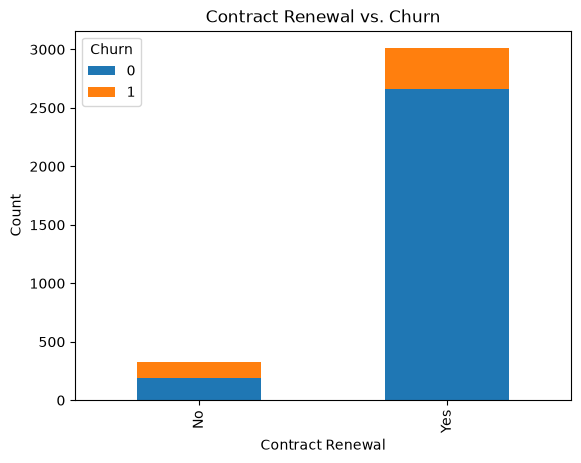

In [9]:
import matplotlib.pyplot as plt

# Bar chart for contract renewal vs churn
churn_counts =  pd.crosstab(df['ContractRenewal'], df['Churn']) # YOUR CODE HERE

# Chart options provided
churn_counts.plot(kind='bar', stacked=True)
plt.title('Contract Renewal vs. Churn')
plt.xlabel('Contract Renewal')
plt.ylabel('Count')
plt.show()

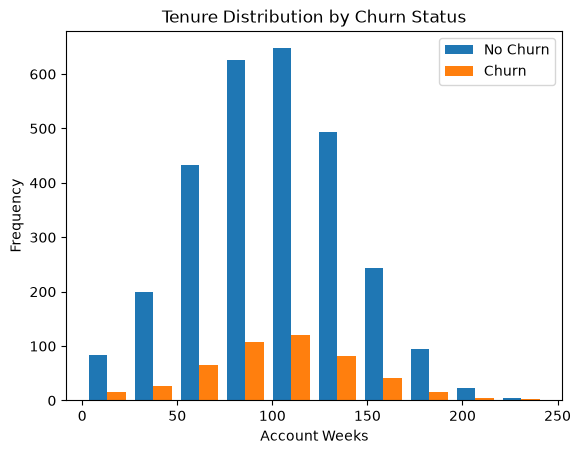

In [10]:
import matplotlib.pyplot as plt

# Histogram for tenure distribution
# plt.hist(# YOUR CODE HERE)
plt.hist([non_churned['AccountWeeks'], 
            churned['AccountWeeks']], 
            label=['No Churn', 'Churn'])


# Chart options provided
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Account Weeks')
plt.ylabel('Frequency')
plt.legend()
plt.show()

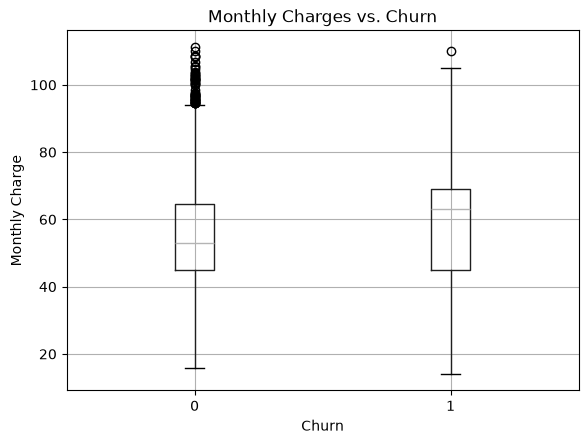

In [11]:
import matplotlib.pyplot as plt

# Box plot for monthly charges
df.boxplot(column='MonthlyCharge', by='Churn')# YOUR CODE HERE)

# Chart options provided
plt.title('Monthly Charges vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charge')
plt.suptitle('')  # Remove the default suptitle
plt.show()

#### Paso 3.3: Interpretar Visualizaciones
Interpretar las visualizaciones e identificar ideas clave sobre los factores que influyen en la rotación. Ingresa tus observaciones en la celda a continuación. Estas no serán calificadas, pero esto puede ser útil si deseas agregar esto a tu portafolio.


Enter your observations about the visualizations here:

- Observation 1: 
- Observation 2: 
- Observation 3: 

- Observación 1: Los clientes que cancelaron su contrato tienden a no haber renovado previamente sus contratos (mayor tasa de cancelación en quienes no renuevan).
- Observación 2: La distribución de permanencia (Account Weeks) es muy similar entre ambos grupos, aunque los clientes que cancelan tienen un promedio ligeramente mayor.
- Observación 3: Los clientes que cancelaron el servicio tienden a tener cargos mensuales más elevados en comparación con los clientes que se mantienen activos.

### 4. Construcción y Evaluación del Modelo de Aprendizaje Automático (20 minutos)
#### Paso 4.1: Elegir un Algoritmo de Clasificación y Entrenar el Modelo
Importar un algoritmo de clasificación adecuado (`LogisticRegression` en este caso) y crear una instancia del mismo (proporcionada).

Configurar `max_iter = 1000` en nuestro modelo de Regresión Logística significa que le estamos dando un límite de 1000 intentos para aprender los patrones óptimos en los datos, lo cual suele ser un buen valor inicial para permitir la convergencia sin un tiempo de entrenamiento excesivo, aunque el número ideal puede variar dependiendo del conjunto de datos específico.


In [12]:
from sklearn.linear_model import LogisticRegression

# Create an instance of the Logistic Regression model (provided)
model = LogisticRegression(max_iter = 1000)

# Train the model
### YOUR CODE HERE ###
model.fit(x_train, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

#### Paso 4.2: Hacer predicciones
Utilice el modelo entrenado para hacer predicciones en los datos de prueba.


In [13]:
# Make predictions on the test set
y_pred =  model.predict(x_test) # YOUR CODE HERE

#### Paso 4.3: Evaluar el Modelo
Evalúe el rendimiento del modelo utilizando métricas apropiadas (`accuracy`, `precision`, `recall`, `f1`).

**Nota:** Para fines de calificación, calcule y almacene cada una de estas métricas en las siguientes variables:
- `accuracy`
- `precision`
- `recall`
- `f1`


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate the model
# Round all values to 3 decimal places

accuracy = round(accuracy_score(y_test, y_pred), 3)
precision = round(precision_score(y_test, y_pred), 3)
recall = round(recall_score(y_test, y_pred), 3)
f1 = round(f1_score(y_test, y_pred), 3)

print(f"Accuracy: {accuracy}") # Expected: approximately 0.867
print(f"Precision: {precision}") # Expected: approximately 0.604
print(f"Recall: {recall}") # Expected: approximately 0.203
print(f"F1 Score: {f1}") # Expected: approximately 0.304

Accuracy: 0.866
Precision: 0.596
Recall: 0.196
F1 Score: 0.295


#### Verifica tus resultados:


In [15]:
# Checking accuracy
print(f"Accuracy: {accuracy}")

Accuracy: 0.866


In [16]:
# Checking precision
print(f"Precision: {precision}")

Precision: 0.596


In [17]:
# Checking recall
print(f"Recall: {recall}")

Recall: 0.196


In [18]:
# Checking f1
print(f"F1 Score: {f1}")

F1 Score: 0.295


### 5. Presentando Resultados en un Informe Integral
#### Paso 5.1: Compilar los Resultados
Compila tu análisis, visualizaciones y resultados de evaluación del modelo en un informe integral. Complétalos según las instrucciones a continuación. Esto no será calificado, pero puede ser útil si deseas agregar esto a tu portafolio.
- `Introducción:` Escribe una o dos oraciones describiendo el propósito de este análisis.
- `Exploración de Datos:` Escribe una o dos oraciones destacando los factores clave en la rotación de clientes.
- `Construcción y Evaluación del Modelo:` Escribe una o dos oraciones describiendo cómo se entrenó tu modelo, y las tasas de precisión, exactitud y recuperación.
- `Ideas Clave:` Agrega dos o tres viñetas resumiendo tus hallazgos.
- `Recomendaciones:` Agrega dos o tres viñetas con las recomendaciones que harías basándote en este análisis.


# Informe de Análisis de Cancelación de Clientes

## Introducción

- El objetivo de este análisis es identificar los factores clave que influyen en la pérdida de clientes y construir un modelo predictivo de regresión logística para detectar cuentas en riesgo de deserción.

## Exploración de Datos

- Hemos detectado que los clientes que no renuevan su contrato y aquellos con cargos mensuales más altos presentan tasas significativamente más elevadas de cancelación de servicios.


## Construcción y Evaluación del Modelo

- Se entrenó un modelo de Regresión Logística. Tras evaluarlo, obtuvimos un Accuracy de 0.866 (86.6%), una Precisión de 0.596 (59.6%), un Recall de 0.196 (19.6%) y un F1-Score de 0.295.

## Ideas Clave

- Los cargos mensuales más altos actúan como un factor de disuasión importante, aumentando la rotación.
- Los contratos no renovados a largo plazo son un indicador sumamente crítico de pérdida inminente de clientes.
- Aunque el modelo es preciso en términos generales (Accuracy de 86.6%), su capacidad de detectar a todos los clientes que se darán de baja (Recall de 19.6%) es baja, lo que indica que se requiere explorar otros modelos o añadir más características.


## Recomendaciones

- Ofrecer beneficios de fidelización o descuentos dirigidos a clientes con cargos mensuales altos para reducir la deserción.
- Diseñar campañas de retención proactivas cuando un cliente esté cerca del vencimiento de su contrato y no haya renovado de manera automática.


## Consejos y trucos
- Use la "hoja de referencia rápida de pandas" para una referencia rápida de la sintaxis en operaciones con DataFrame.
- Consulte la "documentación de Scikit-Learn" para ejemplos y explicaciones de modelos de clasificación.
- Use Matplotlib para crear visualizaciones informativas. Consulte varios materiales en el Curso 2.

¡Buena suerte con su análisis de cancelación de clientes!
